In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("sumithsingh/blood-cell-images-for-cancer-detection")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/sumithsingh/blood-cell-images-for-cancer-detection


In [2]:
import os
import shutil
from sklearn.model_selection import train_test_split

# Path to the downloaded dataset
dataset_path = path

# Define destination directories for training and validation sets
train_dir = 'dataset_split/train'
val_dir = 'dataset_split/val'

# Create directories if they don't exist
os.makedirs(train_dir, exist_ok=True)
os.makedirs(val_dir, exist_ok=True)

print(f"Original dataset found at: {dataset_path}")

# Get a list of subdirectories (classes) in the dataset
# Assume dataset_path contains subdirectories, each representing a class
# Example: dataset_path/class1/, dataset_path/class2/

# Search for the subdirectory containing the sub-classes within dataset_path. Often, datasets from Kagglehub
# will have a single sub-folder containing all images or subsequent sub-folders.
# Trying to find 'dataset_path/blood-cell-images-for-cancer-detection/'

subdirs = [d for d in os.listdir(dataset_path) if os.path.isdir(os.path.join(dataset_path, d))]

# If there's a single subdirectory that seems to be the dataset's root, dive into it
if len(subdirs) == 1 and os.path.isdir(os.path.join(dataset_path, subdirs[0])):
    actual_data_path = os.path.join(dataset_path, subdirs[0])
    print(f"Detected actual data directory at: {actual_data_path}")
else:
    actual_data_path = dataset_path
    print(f"Using the root path as the actual data path: {actual_data_path}")

# Now get the list of classes from actual_data_path
classes = [d for d in os.listdir(actual_data_path) if os.path.isdir(os.path.join(actual_data_path, d))]

if not classes:
    print(f"No class directories found in {actual_data_path}. Please check the dataset structure.")
else:
    print(f"Found classes: {classes}")

    # Split each class into training and validation sets
    for class_name in classes:
        class_path = os.path.join(actual_data_path, class_name)
        images = [os.path.join(class_path, img) for img in os.listdir(class_path) if img.endswith(('.png', '.jpg', '.jpeg'))]

        if not images:
            print(f"No images found in class {class_name}")
            continue

        # Split images into training and validation (80% train, 20% validation)
        train_images, val_images = train_test_split(images, test_size=0.2, random_state=42)

        # Create class subdirectories in train and val directories
        os.makedirs(os.path.join(train_dir, class_name), exist_ok=True)
        os.makedirs(os.path.join(val_dir, class_name), exist_ok=True)

        # Copy images to their respective directories
        for img_file in train_images:
            shutil.copy(img_file, os.path.join(train_dir, class_name, os.path.basename(img_file)))
        for img_file in val_images:
            shutil.copy(img_file, os.path.join(val_dir, class_name, os.path.basename(img_file)))

        print(f"Class '{class_name}' split: {len(train_images)} images for training, {len(val_images)} images for validation.")

    print("Dataset splitting process completed.")
    print(f"Training set saved at: {train_dir}")
    print(f"Validation set saved at: {val_dir}")

Original dataset found at: /kaggle/input/datasets/sumithsingh/blood-cell-images-for-cancer-detection
Using the root path as the actual data path: /kaggle/input/datasets/sumithsingh/blood-cell-images-for-cancer-detection
Found classes: ['monocyte', 'basophil', 'erythroblast', 'seg_neutrophil', 'myeloblast']
Class 'monocyte' split: 800 images for training, 200 images for validation.
Class 'basophil' split: 800 images for training, 200 images for validation.
Class 'erythroblast' split: 800 images for training, 200 images for validation.
Class 'seg_neutrophil' split: 800 images for training, 200 images for validation.
Class 'myeloblast' split: 800 images for training, 200 images for validation.
Dataset splitting process completed.
Training set saved at: dataset_split/train
Validation set saved at: dataset_split/val


## Check GPU Activity

In [3]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)

# Check if GPU is available
gpu_available = tf.config.list_physical_devices('GPU')
if gpu_available:
    print(f"GPU is available: {gpu_available}")
    # Optionally set TensorFlow to use GPU memory growth to avoid allocating all memory at once
    for gpu in gpu_available:
        tf.config.experimental.set_memory_growth(gpu, True)
else:
    print("GPU is NOT available. Training will run on CPU.")

2026-06-13 03:55:48.876547: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781322949.073529      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781322949.131104      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1781322949.609710      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781322949.609750      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781322949.609752      58 computation_placer.cc:177] computation placer alr

TensorFlow version: 2.19.0
GPU is available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Build VGG Model for Image Classification

In [4]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Define image dimensions and batch size
IMAGE_SIZE = (224, 224) # VGG16 expects 224x224 input
BATCH_SIZE = 32
NUM_CLASSES = len(classes) # 'classes' variable from previous cell

# Load the pre-trained VGG16 model without the top (classification) layer
vgg = VGG16(input_shape=IMAGE_SIZE + (3,), weights='imagenet', include_top=False)

# Freeze the layers of the VGG16 model so they are not updated during training
for layer in vgg.layers:
    layer.trainable = False

# Add custom classification layers on top of VGG16
x = Flatten()(vgg.output)
x = Dense(units=256, activation='relu')(x)
x = Dropout(0.5)(x) # Add dropout for regularization
output = Dense(units=NUM_CLASSES, activation='softmax')(x) # Output layer for 5 classes

# Create the final model
model = Model(inputs=vgg.input, outputs=output)

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])

model.summary()

I0000 00:00:1781322962.264947      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,138,757 (80.64 MB)

 Trainable params: 6,424,069 (24.51 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

## Prepare Data Generators and Train the Model

In [5]:
# Create data generators for training and validation with data augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(rescale=1./255) # Only rescale for validation

# Load images from directories
train_generator = train_datagen.flow_from_directory(
    train_dir, # 'train_dir' from previous cell
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_generator = val_datagen.flow_from_directory(
    val_dir, # 'val_dir' from previous cell
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

# Train the model
EPOCHS = 10 # You can increase this for better performance
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // BATCH_SIZE,
    validation_data=val_generator,
    validation_steps=val_generator.samples // BATCH_SIZE,
    epochs=EPOCHS
)

Found 4000 images belonging to 5 classes.
Found 1000 images belonging to 5 classes.
Epoch 1/10


I0000 00:00:1781322967.090736     123 service.cc:152] XLA service 0x7cd06000ea30 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1781322967.090770     123 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1781322967.580564     123 cuda_dnn.cc:529] Loaded cuDNN version 91002


  2/125 ━━━━━━━━━━━━━━━━━━━━ 8s 72ms/step - accuracy: 0.1875 - loss: 1.9225  

I0000 00:00:1781322976.120722     123 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


125/125 ━━━━━━━━━━━━━━━━━━━━ 58s 378ms/step - accuracy: 0.7003 - loss: 0.7836 - val_accuracy: 0.9375 - val_loss: 0.2355
Epoch 2/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 46s 370ms/step - accuracy: 0.8865 - loss: 0.3479 - val_accuracy: 0.9375 - val_loss: 0.1842
Epoch 3/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 46s 371ms/step - accuracy: 0.9085 - loss: 0.2771 - val_accuracy: 0.9587 - val_loss: 0.1274
Epoch 4/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 47s 375ms/step - accuracy: 0.9290 - loss: 0.2297 - val_accuracy: 0.9567 - val_loss: 0.1148
Epoch 5/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 47s 372ms/step - accuracy: 0.9373 - loss: 0.1960 - val_accuracy: 0.9617 - val_loss: 0.1068
Epoch 6/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 47s 378ms/step - accuracy: 0.9383 - loss: 0.1808 - val_accuracy: 0.9577 - val_loss: 0.1087
Epoch 7/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 47s 379ms/step - accuracy: 0.9430 - loss: 0.1707 - val_accuracy: 0.9597 - val_loss: 0.1036
Epoch 8/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 47s 375ms/step - accuracy: 0.9470 - loss: 0.1615 - val

## Summarize Training Results

In [6]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

print("\n--- Training Summary ---")

# Get the final training and validation accuracy and loss
final_train_loss = history.history['loss'][-1]
final_train_accuracy = history.history['accuracy'][-1]
final_val_loss = history.history['val_loss'][-1]
final_val_accuracy = history.history['val_accuracy'][-1]

print(f"Final Training Loss: {final_train_loss:.4f}")
print(f"Final Training Accuracy: {final_train_accuracy:.4f}")
print(f"Final Validation Loss: {final_val_loss:.4f}")
print(f"Final Validation Accuracy: {final_val_accuracy:.4f}")

# Evaluate the model on the validation set
loss, accuracy = model.evaluate(val_generator, verbose=0)
print(f"\nValidation Loss (from evaluate): {loss:.4f}")
print(f"Validation Accuracy (from evaluate): {accuracy:.4f}")

# Predict probabilities for the validation set
Y_pred = model.predict(val_generator, val_generator.samples // BATCH_SIZE + 1)
y_pred_classes = np.argmax(Y_pred, axis=1)
y_true_classes = val_generator.classes[val_generator.index_array]

# Get class labels from the generator
class_labels = list(val_generator.class_indices.keys())

# Print classification report
print("\n--- Classification Report ---")
print(classification_report(y_true_classes, y_pred_classes, target_names=class_labels))

# Print confusion matrix
print("\n--- Confusion Matrix ---")
print(confusion_matrix(y_true_classes, y_pred_classes))


--- Training Summary ---
Final Training Loss: 0.1500
Final Training Accuracy: 0.9507
Final Validation Loss: 0.0931
Final Validation Accuracy: 0.9718

Validation Loss (from evaluate): 0.0927
Validation Accuracy (from evaluate): 0.9720
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 90ms/step

--- Classification Report ---
                precision    recall  f1-score   support

      basophil       0.17      0.18      0.18       200
  erythroblast       0.21      0.20      0.21       200
      monocyte       0.19      0.20      0.19       200
    myeloblast       0.18      0.18      0.18       200
seg_neutrophil       0.21      0.21      0.21       200

      accuracy                           0.19      1000
     macro avg       0.19      0.19      0.19      1000
  weighted avg       0.19      0.19      0.19      1000


--- Confusion Matrix ---
[[37 41 39 37 46]
 [38 40 35 48 39]
 [51 36 39 38 36]
 [42 34 54 36 34]
 [44 37 38 39 42]]


## Display Training Plots

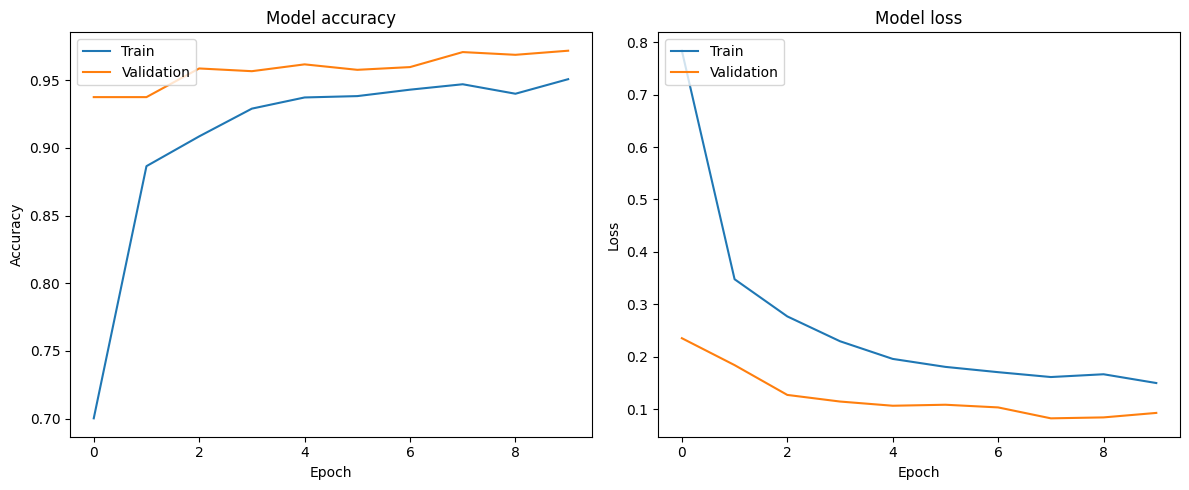

In [7]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()